# Вычислительная математика
## 4.3 Основы метода Монте-Карло

Содержание семинара:
- "Школьный" пример. Вычисление числа $\pi$
    - Идея и реализация
    - Анализ погрешности
- Интегрирование методом Монте-Карло
    - Общий подход
    - Проблемы некомпактного носителя
    - Пример
    - Лирика: когда имеет смысл использовать алгоритмы Монте-Карло?
- Монте-Карло в генерации точек из распределений (сэмплирование)
    - Формулировка задачи
    - Алгоритм Метрополиса-Хастингса (Markov chain Monte Carlo)
    - Семплирование по Гиббсу
    - Пример - генерация гауссова распределения из равномерного
- Двумерная модель Изинга - вычисление физических величин методом Монте-Карло

## "Школьный" пример. Вычисление числа $\pi$
### Идея и реализация

Самый классический пример - вычисление числа $\pi$ как площадь единичного круга. 

Идея, лежащая в основе Монте-Карло подхода, на самом деле очень проста. Будем случайным образом выбирать точки из квадрата $(x, y) \in[-1,1] \times[-1,1]$. Тогда доля точек, попавших в круг, будет равна отношению площади круга к площади квадрата:

$$
\frac{\pi}{4}=\frac{S_{\circ}}{S_{\square}} \equiv \lim _{N \rightarrow \infty} \frac{\widetilde{\pi}_N}{4}
$$

где введено приближенное значение числа $\pi$ на N-м шаге.

$$
\widetilde{\pi}_N=4 \times \frac{\sum_{i=1}^N \theta\left(1-x_i^2-y_i^2\right)}{N}
$$

Здесь $\theta(x)=\left\{\begin{array}{ll}1, & x \geq 0 \\ 0, & x<0\end{array}-\right.$ стандартная функция Хевисайда.

In [1]:
### Визуализация на python
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from numba import njit

# set up the figure and axes
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

# draw a unit circle
circle = plt.Circle((0, 0), 1, edgecolor='black', fill=False)
ax.add_patch(circle)

# initialize the scatter plot
scatter = ax.scatter([], [], s=10)  # use s=10 for original size

# generate the random points outside of the update function
n_max = 25000
points = np.random.uniform(-1, 1, size=(n_max, 2))
inside = np.linalg.norm(points, axis=1) <= 1

# define the Monte Carlo method
def monte_carlo(n, points, inside):
    num_inside = np.sum(inside[:n])
    if num_inside == 0:
        pi = 0
    else:
        pi = 4 * num_inside / n
    return pi

# define the update function for the animation
def update(frame, points, inside):
    n = frame * 1000
    pi = monte_carlo(n, points, inside)
    scatter.set_offsets(points[:n])
    scatter.set_color(np.where(inside[:n], 'blue', 'red'))
    scatter.set_sizes(np.full(n, 3))  # decrease size by a factor of 3
    ax.set_title(f"n = {n}, pi = {pi:.4f}")
    return scatter,

# create the animation
ani = animation.FuncAnimation(fig, update, fargs=(points, inside), frames=25, interval=200)

# display the animation
plt.close(ani._fig)
from IPython.display import HTML
HTML(ani.to_jshtml())


### Анализ погрешности

Из вида нашего приближения:

$$
\widetilde{\pi}_N=4 \times \frac{\sum_{i=1}^N \theta\left(1-x_i^2-y_i^2\right)}{N}
$$

Ясно, что $\widetilde{\pi}_N$ - это сумма независимых равных случайных величин. Отсюда для неё верна __центральная предельная теорема__ - отсюда для оценки погрешности достаточно определить дисперсию:

$$
\left\langle\left\langle\tilde{\pi}_N^2\right\rangle\right\rangle = \frac{1}{N^2} \cdot N \cdot \left\langle\left\langle\tilde{\pi}_1^2\right\rangle\right\rangle=\frac{1}{N} \cdot \left(\left\langle\tilde{\pi}_1^2\right\rangle-\left\langle\tilde{\pi}_1\right\rangle^2\right) 
$$

где мы вынесли из суммы константу $\frac{1}{N}$ и воспользовались тем фактом, что дисперсии независимых случайных величин можно просто складывать. Итого, раскрывая последнее: 

$$
\left\langle\left\langle\tilde{\pi}_N^2\right\rangle\right\rangle =\frac{16}{N^2} \cdot N\left(\left\langle\theta\left(1-x^2-y^2\right)^2\right\rangle-\left\langle\theta\left(1-x^2-y^2\right)\right\rangle^2\right)
$$

С учётом $\theta(x)=\theta(x)^2$, считаем интеграл

$$
\langle\theta(1-x-y)\rangle \equiv \int_{-1}^1 \frac{d x}{2} \int_{-1}^1 \frac{d y}{2} \cdot \theta\left(1-x^2-y^2\right)=\frac{\pi}{4}
$$

Итого, дисперсия:

$$
\left\langle\left\langle\widetilde{\pi}_N^2\right\rangle\right\rangle=\frac{16}{N} \cdot\left(\frac{\pi}{4}-\frac{\pi^2}{16}\right)=\frac{\pi(4-\pi)}{N} \approx \frac{2.70}{N}
$$

Центральная предельная теорема в таком случае гласит, что при больших $N \gg 1$, случайная величина $\widetilde{\pi}_N$ будет распределена по нормальному распределению со средним значением $\left\langle\widetilde{\pi}_N\right\rangle=\pi$ и дисперсией $\sigma_{\tilde{\pi}_N}^2=$ $2.70 / N$


$$
P\left(\widetilde{\pi}_N\right)=\frac{1}{\sqrt{2 \pi \sigma_{\widetilde{\pi}_N}^2}} \exp \left(-\frac{\left(\tilde{\pi}_N-\left\langle\tilde{\pi}_N\right\rangle\right)^2}{2\left\langle\left\langle\tilde{\pi}_N^2\right\rangle\right\rangle}\right)
$$

От этой формулы, в действительности, нам необходимо только следующее: вероятность отклонения $\widetilde{\pi}_N$ от своего среднего значения $\pi$ больше, чем, на $\sigma_{\tilde{\pi}_N}$, достаточно мала. А если взять, скажем, $5 \sigma_{\tilde{\pi}_N}-$ то она будет исчезающе мала.

В частности, если оцениваем погрешность как попадание в первый доверительный интервал, то достаточно:

$$
\sigma_{\tilde{\pi}_N}=\sqrt{\frac{2.70}{N}} < \epsilon \; \Leftrightarrow \; N \geq N^*=\frac{C}{\epsilon^2}
$$

Ключевой же вывод тут следующий: оптимальное число шагов зависит от желаемой точности как $N^*=O\left(1 / \epsilon^2\right)$. Этот результат совершенно универсальный для Монте-Карло алгоритмов, он основывается лишь на центральной предельной теореме.

In [2]:
### Проверка рассуждений на python

import random
import math
import matplotlib.pylab as plt
import numpy as np

N = 1000000
count = 0
for i in range(N):
    x = random.uniform(-1, 1)
    y = random.uniform(-1, 1)
    if (x**2 + y**2 <= 1):
        count += 1
print(4*count/N)

3.142164


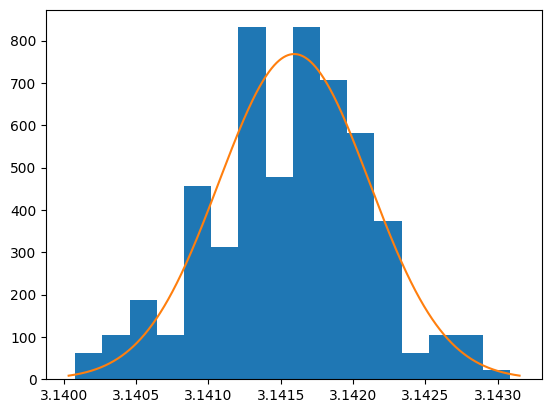

In [3]:
### Проверка рассуждений на python

N = 10000000  
M = 256
pis = []
for i in range(M):
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)
    pis.append(4*np.sum(x**2 + y**2 <= 1) / N)

plt.hist(pis, bins=16, density=True)
sigma = np.sqrt(math.pi*(4-math.pi)/N)
xs = np.arange(math.pi - 3*sigma, math.pi + 3*sigma, 1e-6)
plt.plot(xs, 1/np.sqrt(2*math.pi*sigma**2)*np.exp(-(xs - math.pi)**2 / 2 / sigma**2))

## Интегрирование методом Монте-Карло
### Общий подход

Давайте теперь рассмотрим, как можно обобщить этот метод. Пусть нам необходимо вычислить какой-то многомерный интеграл по какой-то области $\Omega \subset \mathbb{R}^D$ следующего вида:

$$
I=\int_{\boldsymbol{r} \in \Omega} d^D \boldsymbol{r} f(\boldsymbol{r}), \quad \boldsymbol{r}=\left(x_1, \ldots, x_D\right)
$$

Сразу напрашивается тривиальное обобщение: давайте просто случайным образом выбирать точку из области $\boldsymbol{r}_i \in \Omega$ (предположим, у нас имеется такой алгоритм); тогда мы могли бы записать:

$$
I=V_{\Omega} \int_{\boldsymbol{r} \in \Omega} \frac{d^D \boldsymbol{r}}{V_{\Omega}} f(\boldsymbol{r})=V_{\Omega}\langle f(\boldsymbol{r})\rangle_{\Omega} \underset{N \gg 1}{\approx} V_{\Omega} \times \frac{\sum_{i=1}^N f\left(\boldsymbol{r}_i\right)}{N} .
$$

(где $V_{\Omega}-$ объём области $\Omega$, который, как мы предполагаем, мы тоже умеем вычислять). 

По сути, это обобщение той самой предыдущей формулы для вычисления числа $\pi$ при $V_{\Omega}-$ квадрат, $f(\boldsymbol{r})$ - индикаторная функция единичного круга.

Какие в этом метода есть подводные камни?

### Проблема некомпактного носителя

Первый подводный камень заключается в том, что будет если функция $f(\boldsymbol{r})$ отлична от нуля во всём пространстве? Формально , это соответствует $\Omega=\mathbb{R}^D$ и $V_{\Omega}=\infty$.

Первый "наивный" подход - __обрезка функции__. 

Вместо области $\Omega$ посчитаем интеграл на некоторой меньшую компактную область $\Omega^{\prime} \subset \Omega$, где функция существенно отлична от нуля. Некомпактный остаток на $\Omega \backslash \Omega^{\prime}$ оценим аналитически. 

У этого подхода есть много проблем:

- Сложность аналитической оценки остатка
- Увеличение области $\Omega$ повышает погрешность метода Монте-Карло, т.к. $\sigma_I^2 \propto V_{\Omega}^2$
- В случае непрямоугольной $\Omega^{\prime}$ (например, какая-нибудь кривая), то выбирать случайным образом из неё точки тоже является сложной задачей

Второй "крутой" подход - __выбор функции распределения__.

Вообще говоря, нам необязательно выбирать точку из равномерного распределения. Давайте модифицируем наш интеграл следуюшим образом:

$$
I=\int d^D \boldsymbol{r} f(\boldsymbol{r}) \equiv \int P(\boldsymbol{r}) d^D \boldsymbol{r} \cdot \frac{f(\boldsymbol{r})}{P(\boldsymbol{r})}
$$

Если функция $P(\boldsymbol{r}) \geq 0$ и $\int d^D \boldsymbol{r} P(\boldsymbol{r})=1$, то эту формулу можно интерпретировать следующим образом:

$$
I \equiv\left\langle\frac{f(\boldsymbol{r})}{P(\boldsymbol{r})}\right\rangle \approx I_N \equiv \frac{1}{N} \sum_{i=1}^N \frac{f\left(\boldsymbol{r}_i\right)}{P\left(\boldsymbol{r}_i\right)}
$$

где $\boldsymbol{r}_i$ выбираются из известного распределения $P(\boldsymbol{r})$.

Наша задача заключается в выборе из этого набора распределения $P(\boldsymbol{r})$, который максимально похож на функцию $f(\boldsymbol{r})$ - тем самым мы минимизируем дисперсию $\left\langle\left\langle(f(\boldsymbol{r}) / P(\boldsymbol{r}))^2\right\rangle\right\rangle$. 

Возникает вопрос, а как нам генерировать $\boldsymbol{r}_i$ из определенного распределения $P(\boldsymbol{r})$? Конечно, в python уже встроены алгоритмы генерации многих распределений и для многих простых случаев они подойдут, но в случае практических задач придётся научиться генерировать точки из нужного нам распределения.

### Пример

Давайте разберём тривиальный пример. Пусть мы хотим сосчитать такой интеграл:

$$
I=\int_{-\infty}^{\infty} d x \exp \left(-|x|^3\right)=2 \Gamma\left(\frac{4}{3}\right) \approx 1.786
$$

(тут $\Gamma(x)$ - так называемая Гамма-функция Эйлера). Пусть мы хотим вычислить интеграл с точностью $\epsilon=10^{-3}$. Действовать будем «на глаз».

__Уменьшение области интегрирования__ 

Построим подынтегральную функцию, и пристально на неё посмотрим. Судя по графику, кажется, что существенно отлична от нуля примерно на отрезке $(-2,2)$. Это будет нашей отправной точкой.

Сама функция на краях этого отрезка уже достаточно мала: $e^{-8} \approx 3 \cdot 10^{-4}$, это даёт нам наивную оценку сверху для погрешности от такого приближения (точная оценка даёт $2 \int_2^{\infty} \exp \left(-x^3\right) d x \approx 5 \cdot 10^{-5}$, но чтобы её получить, нужно уметь этот интеграл считать...). Такая погрешность нас вполне удовлетворяет, поэтому мы реализуем следующий алгоритм:

1. Выбираем $N$ случайных точек $x_i$ из отрезка $(-2,2)$
2. Вычисляем $I_N=4 \frac{1}{N} \sum_{i=1}^N f\left(x_i\right)$.

Погрешность этого алгоритма будет равна

$$
\left\langle\left\langle I_N^2\right\rangle\right\rangle=\frac{16}{N}\left\langle\left\langle f^2(x)\right\rangle\right\rangle=\frac{16}{N}\left(\int_{-2}^2 \frac{d x}{4} f^2(x)-\left(\int_{-2}^2 \frac{d x}{4} f(x)\right)^2\right) \approx \frac{2.48}{N}
$$

__Выбор функции распределения__  

А давайте теперь вместо этого попробуем приблизить эту функцию при помощи нормального распределения $P(x)=e^{-x^2 / 2 \sigma^2} / \sqrt{2 \pi \sigma^2}$. 

Дисперсию этого распределения $\sigma$ мы опять выберем «на глаз», чтобы функция распределения была __максимально похожей__ на подынтегральное выражение. Автору хорошим приближением показалось значение $\sigma=0.5$. Так и поступим:

1. Выбираем $N$ случайных точек $x_i$ из нормального распределения с нулевым средним и дисперсией $\sigma=0.5$ ( распределение $P(x)$ ).
2. Вычисляем $I_N=\frac{1}{N} \sum_{i=1}^N \frac{f\left(x_i\right)}{P\left(x_i\right)}$.

Погрешность этого алгоритма будет равна

$$
\left\langle\left\langle I_N^2\right\rangle\right\rangle=\frac{1}{N}\left\langle\left\langle\left(\frac{f(x)}{P(x)}\right)^2\right\rangle\right\rangle=\frac{1}{N}\left(\int_{-\infty}^{\infty} d x P(x) \frac{f^2(x)}{P^2(x)}-\left[\int_{-\infty}^{\infty} d x P(x) \frac{f(x)}{P(x)}\right]^2\right) \approx \frac{0.43}{N}
$$

Ключевой вывод, который мы можем сделать из этого примера: выбирая правильным образом распределение $P(\boldsymbol{r})$, можно заметным образом (в нашем случае - почти в шесть раз!) ускорить алгоритм.

### Лирика: когда имеет смысл использовать Монте-Карло алгоритмы?

Если мы вспомним прошлые семинары, то в том же методе прямоугольников количество шагов для достижении нужной точности _меньше_:

$$
\delta I / I \propto \epsilon \sim 1 / N
$$

Тогда как в методе Монте-Карло:

$$
\delta I / I \propto \epsilon \sim 1 / \sqrt{N}
$$

А ведь метод прямоугольников был худшим из всех, что мы рассматривали, в плане скорости сходимости. Зачем же нужен Монте-Карло? 

Метод Монте-Карло нужен, когда интегрирование происходит в многомерном пространстве достаточно большой размерности $D$. 

Ведь если мы хотим использовать квадратуру, то нам будет необходимо дискретизовать вдоль каждой пространственной размерности; и если мы апроксимируем интеграл, используя $N$ точек, то каждое пространственное измерение мы будем вынуждены дискретизовать, вводя гораздо меньше - порядка $N^{1 / D}$ - точек. 

Как следствие, общая погрешность квадратурного метода будет вести себя уже как $\delta I / I \propto \frac{1}{N^{m / D}}$, и при достаточно больших $D>2 m$ Монте-Карло метод будет более эффективным (на него $D$ не влияет никак в ассимптотике)

Поэтому ключевой вывод, который отсюда стоит вынести: __метод Монте-Карло эффективен при интегрировании в пространстве достаточно большой размерности__. И как раз основное применение методов Монте-Карло -  случай, когда размерность пространства оказывается астрономически большой (например, фазовое пространство системы большого количество частиц).

## Монте-Карло в генерации точек из распределений (сэмплирование)

### Формулировка задачи

Пусть функция $P(\boldsymbol{r}) \geq 0$ и $\int d^D \boldsymbol{r} P(\boldsymbol{r})=1$. Тогда её можно трактовать как некоторую плотность распределения.

Хотим генерировать точки $\boldsymbol{r}_i$ из этого распределения $P(\boldsymbol{r})$. 

При этом считаем, что у нас уже есть способ генерации простых распределений (равномерное, нормальное).

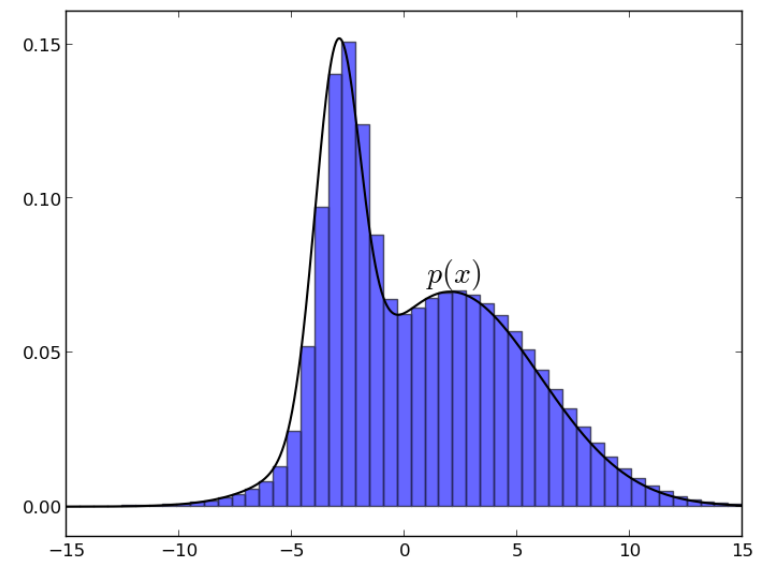

### Алгоритм Метрополиса-Хастингса (Markov chain Monte Carlo)

Данный алгоритм основан на случайном блуждании и по сути своей является марковской цепью. 

Совсем простыми словами, будем блуждать по области определения, при этом на каждом шаге с бОльшей вероятностью идти в сторону увеличения плотности вероятности. Рекомендую перед прочтением следующего посмотреть вывод кода после параграфа.

Введём $q\left(x^{\prime} , \; x\right)$ - __эмпирическая__ плотность вероятности перехода из точки $x$ в точку $x^{\prime}$. Она не обязано как-то соответствовать целевому распределению $P(\boldsymbol{r})$; главное условие на $q\left(x^{\prime} , \; x\right)$ - локальность и умение генерировать из неё точки. Можно думать, что оно вносит консерватизм в систему и не даёт шагам быть слишком большими. 

Естественно, если каким-то образом удалось теоретически получить $q\left(x^{\prime} , \; x\right)$ как __истинную__ вероятность перехода в процессе случайного движения, алгоритм будет работать намного быстрее, но это вовсе необязательно - как правило, хорошо работает многомерный гаусс с маленькой дисперсией.

Сам алгоритм __Метрополиса-Хастингса__ выглядит следующим образом.

1. Выбрать $x^{\prime}$ по распределению $q\left(x^{\prime} , \; x^{(t)}\right)$.

Это как бы кандидат на возможное блуждание. К примеру, можно выбирать $x_{t+1}=x_t+\varepsilon_t$ где $\varepsilon_t \sim N(0,1)$.
   
2. Вычислить
$$
a=\frac{P\left(x^{\prime}\right)}{P\left(x^{(t)}\right)} \frac{q\left(x^{(t)} , \; x^{\prime}\right)}{q\left(x^{\prime}, \; x^{(t)}\right)}
$$

(не надо пугаться, $q\left(x^{(t)} , x^{\prime}\right) / q\left(x^{\prime} , x^{(t)}\right)$ для симметричных распределений, например гауссового, равно 1, это просто поправка на асимметрию);

3. С вероятностью а $\min \left(1, \; a\right)$ генерируем новую точку из распределения $x^{(t+1)}:=x^{\prime}$, иначе остаёмся на этой же точке $x^{(t+1)}:=x^{(t)}$.

Итого, результирующий набор $\{x^{(t)}\}_{t \in T}$ - даст нам произвольную выборку, отвечающую распределению $P(x)$.

__Важные детали__:

- Из-за "вольности" в выборке $q\left(x^{\prime} , \; x^{(t)}\right)$ может возникать корреляция нескольких последующих шагов, что вылезает за применимость цепей Маркова. На практике берут каждый $n$-ый шаг в $\{x^{(t)}\}_{t \in T}$ так, чтобы результирующая выборка отвечала нужным свойствам.

- Начало алгоритма в точке $x^{(0)}$ нужно стараться выбрать близко примерно в середине $P(x)$, т.к. неудачный выбор начальной точки может быть сильноскореллированным. На практике первые, скажем, 1000 шагов всегда отбрасывают (__burn-in__) чтобы точно не словить этот эффект.

- Есть эмпирическое правило - доля отвергнутых кандидатов на блуждание должна быть примерно 0.5 для хорошей скорости. Далеко не всегда работает.

__Реализация на python__

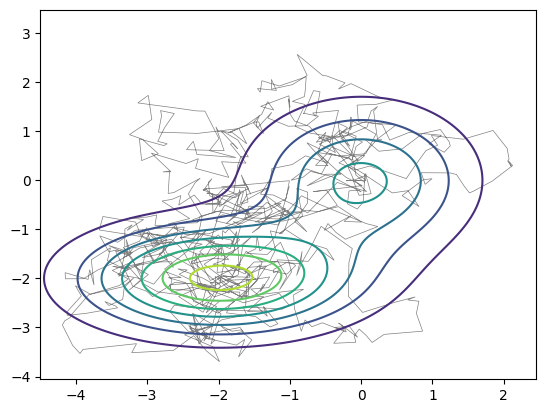

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import matplotlib.mlab as mlab
import scipy
import scipy.stats as stats

delta = 0.025
X, Y = np.meshgrid(np.arange(-4.5, 2.0, delta), np.arange(-3.5, 3.5, delta))

z1 = stats.multivariate_normal([0,0],[[1.0,0],[0,1.0]])
z2 = stats.multivariate_normal([-2,-2],[[1.5,0],[0,0.5]])
def z(x): return 0.4*z1.pdf(x) + 0.6*z2.pdf(x)

Z01 = scipy.stats.multivariate_normal([0, 0], [[1.0, 0.0], [0.0, 1.0]])
Z1 = Z01.pdf(np.dstack((X, Y)))

Z02 = scipy.stats.multivariate_normal([-2, -2], [[1.5, 0], [0, 0.5]])
Z2 = Z02.pdf(np.dstack((X, Y)))


Z = 0.4*Z1 + 0.6*Z2

Q = stats.multivariate_normal([0,0],[[0.05,0],[0,0.05]])
r = [0,0]
samples = [r]
for i in range(0,1000):
	rq = Q.rvs() + r
	a = z(rq)/z(r) 
	if np.random.binomial(1,min(a,1),1)[0] == 1:
		r = rq
		samples.append(r)

codes = np.ones(len(samples), int) * path.Path.LINETO
codes[0] = path.Path.MOVETO

p = path.Path(samples,co h(p, facecolor='none', lw=0.5, edgecolor='gray'))
plt.show()


### Семплирование по Гиббсу

Пусть размерность пространства $X$ очень-очень большая. Генерация произвольного блуждания в такой системе может быть очень трудоёмкой (если вообще не невозможной на компьютере, в случае бесконечномерных пространств). Как выпутаться?

Пусть имеем совместное распределение $P\left(x_1, \ldots, x_D\right)$ для $D$ случайных величин, причём $D$ может быть очень большим. Пусть на шаге $t$ мы уже выбрали какое-то значение $x_i^t$. На каждом шаге делаются следующие действия:

1. Выбирается индекс $i:(1 \leq i \leq D)$. Можно идти последовательно по индексам - так сходимость гарантируется.
2. Выбираем $x_i^{t+1}$ по одномерному распределению $p\left(x_i \mid x_1^t, \ldots, x_{i-1}^t, x_{i+1}^t, \ldots, x_d^t\right)$ алгоритмом Метрополиса-Хастингса, а для остальных индексов значение не меняется: $x_j^{t+1}=x_j^t(\mathrm{j} \neq \mathrm{i})$.

Сэмплирование по Гиббсу - это частный случай алгоритма Метрополиса для распределений $q\left(x^{\prime} , x\right)=p\left(x_i^{\prime} \mid{x}_{-i}\right)$, и вероятность принятия каждого сэмпла получается всегда равна 1 (можете это доказать в качестве упражнения). Поэтому сэмплирование по Гиббсу сходится, и, так как это такое же случайное блуждание по сути, верна та же квадратичная оценка.

Естественно, все ремарки алгоритма Метрополиса-Хастингса насчёт корелированности остаются в силе.

От общего случая блуждания по Метрополису-Гастингсу это отличается тем, что теперь мы двигаемся на каждом шаге вдоль одной из координатных осей; вот соответствующая картинка:  

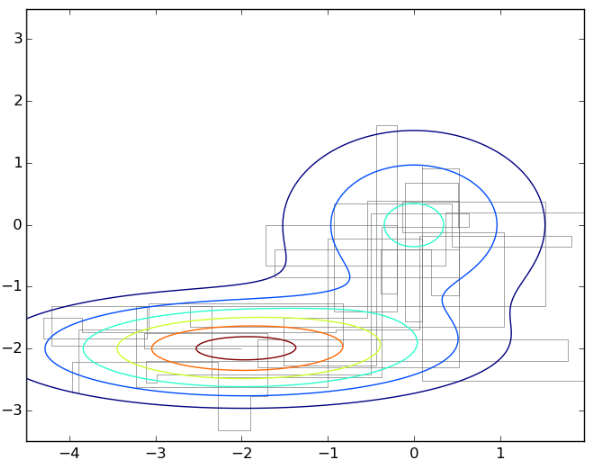

### Пример. Генерация гауссова распределения из равномерного

Доля отвергнутых кандидатов: 0.002913


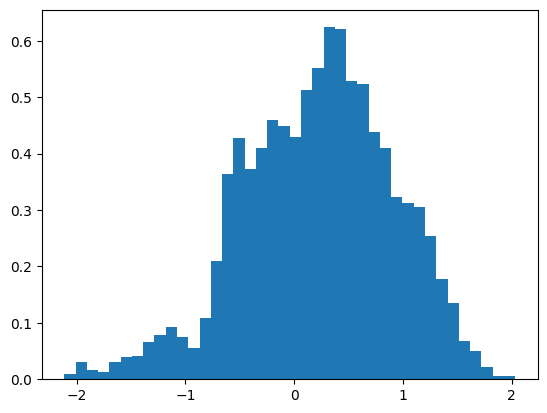

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def proba_density(x):
    
    return 1/np.sqrt(np.pi)*np.exp(-x**2)

x = 0 # Поставим очень плохое начальное приближение
B = 0.01

N = 1000000

xs = np.zeros(N)
xs[0] = x

rejected = 0
for i in range(1, N):
    x_cand = xs[i-1] + np.random.uniform(-B, B)
    
    if proba_density(x_cand)/proba_density(xs[i-1]) >= 1:
        xs[i] = x_cand
        continue
    else:
        if np.random.uniform(0, 1) < proba_density(x_cand)/proba_density(xs[i-1]): # q = 1 т.к. симметричное распределение
            xs[i] = x_cand
            continue
        else:
            xs[i] = xs[i-1]
            rejected  += 1
            continue
plt.hist(xs, bins = 40, density=True)
print(f"Доля отвергнутых кандидатов: {rejected/N}")

array([ 0.        ,  0.00809147,  0.00866982, ..., -0.86928525,
       -0.86934574, -0.86462043])

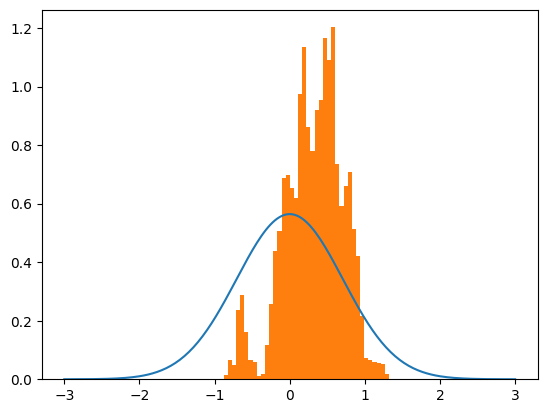

In [6]:
eps = 0.5*1e-2
i_cut = 900000

plt.plot(np.linspace(-3, 3, 200), proba_density(np.linspace(-3, 3, 200)))
_ = plt.hist(xs[i_cut:], bins = 40, density = True)
xs

## Модель Изинга

Это решётка взаимодействующих спинов NxN c периодическими граничными условиями.

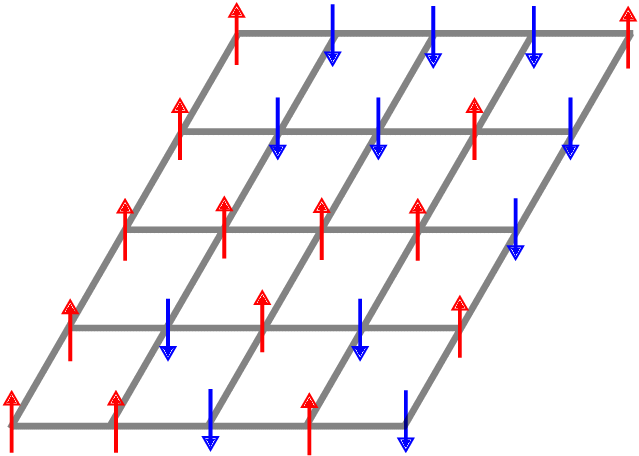

$$
E(S)=-J \sum_{i \sim j} S_i S_j
$$

Алгоритм Метрополиса в данном случае позволяет генерировать элементы из NVT ансамбля согласно распределению Гиббса.

С помощью этого можем получить средние величины, просто усредняя их по получившейся выборке.

In [7]:
from numba import njit, prange

@njit()
def E_calc(system: np.array, N: int) -> float: # Подсчёт энергии с учётом ПГУ
    
    E = 0
    
    for i in range(N):
        for j in range(N):
            
            if (i != 0) and (j != 0):
                E -= (system[i-1, j]*system[i, j] + system[i, j]*system[i, j-1])
                continue
            if (i == 0) and (j != 0):
                E -= (system[N-1, j]*system[i, j] + system[i, j]*system[i, j-1])
                continue
            if (i != 0) and (j == 0):
                E -= (system[i-1, j]*system[i, j] + system[i, j]*system[i, N-1])
                continue
            
    return E

@njit()
def izing(N: int,T: float, steps=5000000):
    
    system = np.ones((N, N)) # Инициализируем систему с сонаправленными спинами. Наш x_0
     
    E = E_calc(system, N) # Считаем энергию
    
    for i in range(steps): # Алгоритм Метрополиса (версия Гиббса)
        
        # выбираем случайный элемент
        i1 = np.random.randint(0, N) 
        i2 = np.random.randint(0, N)
        
        # определяем индексы соседей с учётом ПГУ
        i_up = i1 - 1 
        i_down = i1 + 1
        i_left = i2 - 1
        i_right = i2 + 1
        
        if i_up == -1:
            i_up = N-1
        
        if i_down == N:
            i_down = 0
        
        if i_left == -1:
            i_left = N-1
            
        if i_right == N:
            i_right = 0
        
        # смотрим на изменение энергии при изменении значения спина i1, i2
        deltaE = 2*system[i1, i2]*(system[i_up, i2] + system[i_down, i2] + system[i1, i_left] + system[i1, i_right])
            
        if deltaE < 0: # Если энергия стала ниже, то всегда принимаем новую конфигурацию
            system[i1, i2] *= -1 # измененный system наше x_{t+1} состояние
            E += deltaE # отслеживаем значение энергии
        else:
            if np.random.uniform(0,1) < np.exp(-deltaE/T): # Если нет, то используем рпспределение Гиббса как P(x)
                system[i1, i2] *= -1 # измененный system наше x_{t+1} состояние
                E += deltaE
                
    return E, system.mean() # выводим энергию на последнем получившемся x_t и средний спин на состоянии x_t

In [8]:
from tqdm import tqdm

N = 100
T = 10

Ms = []
Es = []
Ts = np.linspace(1, 3, 50)

#avg E from T
for T in tqdm(Ts):
    
    E, M = 0, 0
    
    # Усредняем 100 раз по разным экспериментам, чтобы избавиться от корреляции
    for i in range(100): 
        deltaE, deltaM = izing(N,T, steps=1000000)
        E += deltaE
        M += deltaM
    E /= 100
    M /= 100
    
    Es.append(E)
    Ms.append(M)

100%|███████████████████████████████████████████████████████████████████████| 50/50 [01:48<00:00,  2.17s/it]


In [9]:
# Теоретические выкладки (ищите сами, откуда :))

from scipy.optimize import fsolve
from scipy.special import ellipk
from scipy.special import ellipe

def T_crit(T_cand):
    return np.sinh(2/T_cand) - 1
T_c_theory = fsolve(T_crit, 2)[0]

def E_ud_theory(T):
    
    kappa = 2*np.sinh(2./T)/(np.cosh(2./T)**2)
    E = 0
    E += -2*np.tanh(2./T)
    E += -(np.sinh(2./T)**2 - 1)/np.sinh(2./T)/np.cosh(2./T)*(2./np.pi*ellipk(kappa**2) - 1)

    return E

def C_theory(T):
    
    kappa = 2*np.sinh(2./T)/(np.cosh(2./T)**2)
    
    C = 4./np.pi
    
    C *= (1./T/np.tanh(2./T))**2
    
    C *= (ellipk(kappa**2) - ellipe(kappa**2) - (1 - np.tanh(2./T)**2)*(np.pi/2 + (2*np.tanh(2./T)**2 - 1)*ellipk(kappa**2)))
    return C


Text(0.5, 1.0, 'E_уд(T)')

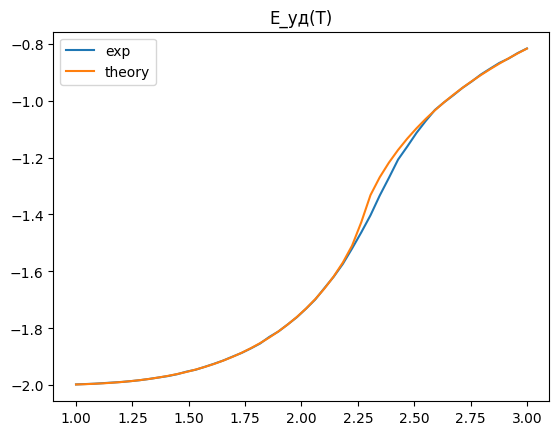

In [10]:
Es = np.array(Es)

Es_theory = E_ud_theory(Ts)

plt.plot(Ts, Es/N**2, label = "exp")
plt.plot(Ts, Es_theory, label = "theory")
plt.legend()
plt.title("E_уд(T)")

Text(0.5, 1.0, 'M(T)')

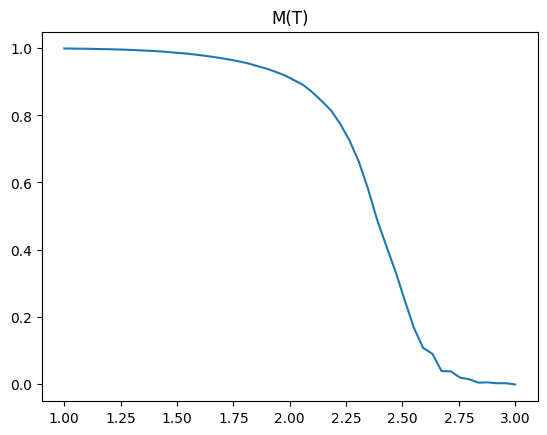

In [11]:
plt.plot(Ts, Ms)
plt.title("M(T)")

Tc_exp = 2.3061224489795915
Tc_theory = 2.269185314213022


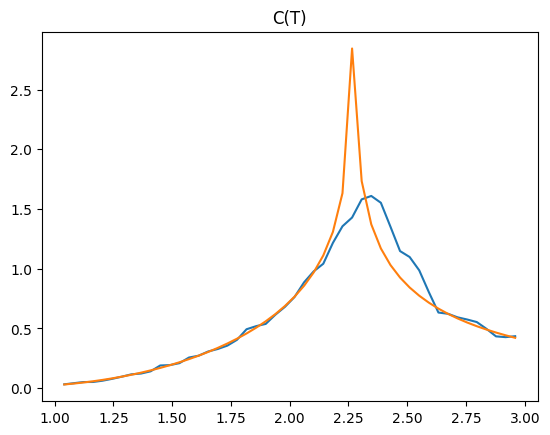

In [12]:
dT = Ts[1] - Ts[0]
Cvs = (Es[2:]-Es[0:-2])/2/dT/N**2

plt.plot(Ts[1:-1], Cvs)
plt.plot(Ts[1:-1], C_theory(Ts[1:-1]))
plt.title("C(T)")
print(f"Tc_exp = {Ts[Cvs.argmax()]}")
print(f"Tc_theory = {T_c_theory}")

## Домашнее задание

__Задание 1. Закон всемирного тяготения__

Используем метод для вычисления силы взаимного притяжения Луны и Земли. Для простоты предположим, что плотности Земли и Луны не зависят от координат и возьмем их средние значения. Для проведения численного эксперимента нам понадобятся следующие физические величины:

$$
\begin{aligned}
& G=6.67 \cdot 10^{-11} \frac{\mathrm{H} \cdot \mathrm{м}^2}{\text { кг }}-\text { гравитационная постоянная; } \\
& m_1=6 \cdot 10^{24} \mathrm{ кг }-\text { масса Земли; } \\
& m_2=7.35 \cdot 10^{22} \text { кг }-\text { масса Луны; } \\
& r=384467000 \mathrm{ м}-\text { pacстояние между Луной и Землей; } \\
& \rho_1=5520 \frac{\mathrm{ кг }}{\mathrm{м}^3}-\text { средняя плотность Земли; } \\
& \rho_2=3346 \frac{\mathrm{кг}}{\mathrm{м}^3}-\text { средняя плотность Луны; } \\
& R_1=6367000 \mathrm{м}-\text { радиус Земли; } \\
& R_2=1737000 \mathrm{м}-\text { радиус Луны. }
\end{aligned}
$$

Поскольку тела сферические со сферически симметричной функцией плотности (константой), то объекты можно рассматривать как точечные и вычислить их силу притяжения по формуле:

$$
F=G \frac{m_1 \cdot m_2}{r^2},
$$

где $m_1$ и $m_2$ массы точечных объектов. Это значение будем использовать для сравнения с результатами вычислений с помощью метода Монте-Карло. По формуле  находим значение силы

$$
F=1.98997 \cdot 10^{20} \mathrm{H} .
$$

Результаты вычислений этой силы с помощью метода Монте-Карло и аналитически сравнить между собой. Построить график зависимости ошибки от числа итераций в логарифмическом масштабе , сделать вывод об асимптотике ошибки.

__Задание 2. Закон всемирного тяготения__

Пусть на однородную пластинку бесконечной площади толщиной $\mathrm{h}$ нормально падает поток нейтронов с энергией $\mathrm{E}_0$. При столкновении с атомами вещества, из которого состоит пластинка, нейтроны могут: а) упруго рассеиваться; б) поглощаться. Пусть при упругом рассеянии: энергия не меняется; равновероятно любое направление рассеяния. Сечения поглощения и сечения рассеяния нейтронов считать известными. Требуется вычислить:
- вероятность прохождения нейтрона сквозь пластинку $Р+$,
- вероятность отражения нейтронов от пластинки $Р-$
- вероятность поглощения нейтрона в пластинке $Р_О$.

__Задание 3. Случайное блуждание__

Рассмотрим одномерное случайное блуждание, где на каждом шаге с вероятностью $1 / 2$ точка движется влево или вправо на единицу длины. Чему равно математическое ожидание расстояния точки от нуля после $T$ шагов? 

Вычислите аналитически, затем промоделируйте численно.

Проанализируйте погрешность (нарисовать график и гистограмму).

__Задание 4. Семплирование по Гиббсу__

Семплируйте по Гиббсу сумму двух гауссианов из разобранного примера на алгоритм Метрополиса-Хастингса.

__Задание 5. Алгоритм Метрополиса-Хастингса - генерация выборок__

Сгенерируйте выборку из функции плотности $\pi(x) \sim \exp \left(-x^2\right)\left(3+\cos (x)+2 \sin (x)+x^2\right)$ применив алгоритм Метрополиса-Хастингса к случайному блужданию $x_{t+1}=x_t+\varepsilon_t$ где $\varepsilon_t \sim N(0,1)$.